# GO-GPT / BioReason-Pro term-prediction assessments

This notebook audits the per-term prediction assessments stored in
`genes/<species>/<gene>/<gene>-gogpt-leaf-predictions.yaml`. Each predicted GO
term carries a `review.assessment` using the de Crecy-Lagard taxonomy
(COR / CNN / LSP / UNC / PLI / NPI / REP), the same scheme used in the 7-gene
*E. coli* replication and in **Table 5** of the manuscript.

> **Transparency note.** On this branch the prediction YAMLs are the raw web-export
> stubs: every term is still `UNC` ("requires manual assessment"). The
> manually-verified distribution reported as Table 5 (≈67% CNN, 11.5% NPI,
> 4.5% COR) was produced on a separate working branch
> (`feat/bioreason-hf-catalogue`). This notebook deliberately computes the
> distribution **from whatever is on disk** rather than hard-coding Table 5, so
> running it here shows the current (un-reviewed) state, and re-running it on the
> review branch reproduces Table 5 exactly.

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd()))
import bioreason_stats as bs

ROOT = bs.find_repo_root()
preds = bs.load_prediction_assessments(ROOT)
n_genes = preds[["species", "gene"]].drop_duplicates().shape[0]
print(f"genes with prediction files: {n_genes}")
print(f"total predicted terms:       {len(preds)}")
print("\nsource methods:")
print(preds.source_method.value_counts().to_string())
preds.head()

genes with prediction files: 139
total predicted terms:       6299

source methods:
source_method
GO-GPT    6299


,species,gene,source_method,term_id,term_label,term_type,assessment,confidence_score,path
0,9CAUD,dfrP,GO-GPT,GO:0004146,dihydrofolate reductase activity,GO_MF,UNC,1,genes/9CAUD/dfrP/dfrP-gogpt-leaf-predictions.yaml
1,9CAUD,dfrP,GO-GPT,GO:0009410,response to xenobiotic stimulus,GO_BP,UNC,1,genes/9CAUD/dfrP/dfrP-gogpt-leaf-predictions.yaml
2,9CAUD,dfrP,GO-GPT,GO:0005737,cytoplasm,GO_CC,UNC,1,genes/9CAUD/dfrP/dfrP-gogpt-leaf-predictions.yaml
3,9CAUD,dfrP,GO-GPT,GO:0005622,cytoplasm,GO_CC,UNC,1,genes/9CAUD/dfrP/dfrP-gogpt-leaf-predictions.yaml
4,AGKCO,fibrolase,GO-GPT,GO:0000287,magnesium ion binding,GO_MF,UNC,1,genes/AGKCO/fibrolase/fibrolase-gogpt-leaf-pre...


## Terms per gene

A genuinely reproducible structural statistic (independent of the manual review state).

In [2]:
per_gene = preds.groupby(["species", "gene"]).size().rename("n_terms")
print(per_gene.describe().round(1).to_string())
print(f"\nmean terms/gene: {per_gene.mean():.1f}")

count    139.0
mean      45.3
std       52.8
min        4.0
25%       12.0
50%       24.0
75%       58.0
max      319.0

mean terms/gene: 45.3


## Assessment distribution

Ordered by the de Crecy-Lagard taxonomy, with glosses.

In [3]:
counts = preds.assessment.value_counts()
order = [a for a in bs.ASSESSMENT_ORDER if a in counts.index]
order += [a for a in counts.index if a not in bs.ASSESSMENT_ORDER]  # any extras
table = pd.DataFrame({
    "count": [counts[a] for a in order],
    "pct": [round(100 * counts[a] / len(preds), 1) for a in order],
    "meaning": [bs.ASSESSMENT_GLOSS.get(a, "?") for a in order],
}, index=order)
table.index.name = "assessment"
print(table.to_string())

            count    pct                                meaning
assessment                                                     
UNC          6299  100.0  Uncertain - cannot validate or refute


saved figures/assessment_distribution.repro.png


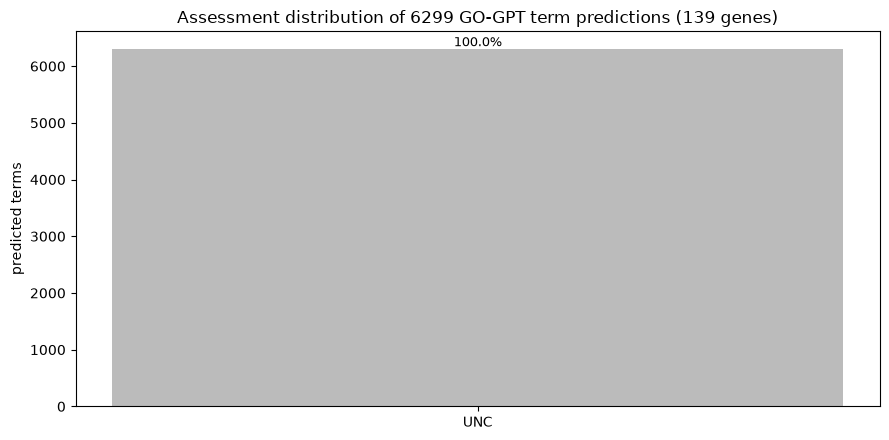

In [4]:
fig, ax = plt.subplots(figsize=(9, 4.5))
colors = {"COR": "#1a7f37", "CNN": "#16527a", "LSP": "#7fb2d6",
          "UNC": "#bbbbbb", "PLI": "#e0902a", "NPI": "#b3261e", "REP": "#7a4ea3"}
ax.bar(table.index, table["count"], color=[colors.get(a, "#888") for a in table.index])
for i, (a, row) in enumerate(table.iterrows()):
    ax.text(i, row["count"], f"{row['pct']}%", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("predicted terms")
ax.set_title(f"Assessment distribution of {len(preds)} GO-GPT term predictions "
             f"({n_genes} genes)")
fig.tight_layout()
outdir = Path("figures")
outdir.mkdir(exist_ok=True)
fig.savefig(outdir / "assessment_distribution.repro.png", dpi=120)
print("saved", outdir / "assessment_distribution.repro.png")
plt.show()

### Interpreting the result

If the printed distribution above is **100% UNC**, you are on a branch with the
raw web-export stubs and the manual term-level review has not been merged here
(see the transparency note at the top). The cell logic is identical to what
produces Table 5; only the input files differ.